### 加载数据

In [137]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.qmc import LatinHypercube
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from sklearn.model_selection import train_test_split
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, read_log
set_config(transform_output="pandas")
init_logger("WalkForward+CPCV+PS")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\WalkForward+CPCV+PS.log


In [2]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2116 只 | 2579 天 | 2016-01-04 ~ 2026-08-14
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2578 天 x 2112 资产 | 列集一致: True


### 预筛选
对初始资产宇宙进行预选择处理，其核心目的是在构建投资组合之前，通过特定的规则筛选出符合条件的资产，从而优化后续的计算效率和模型表现。

In [3]:
from Pre_selection import DropTailCorrelated
from skfolio.pre_selection import SelectKExtremes
from skfolio.pre_selection import DropZeroVariance, DropCorrelated
from skfolio.pre_selection import SelectComplete, SelectNonExpiring, SelectNonDominated
from skfolio import RiskMeasure,PerfMeasure,RatioMeasure
from sklearn.pipeline import Pipeline

In [ ]:
selection_pipe = Pipeline([
        ("complete", SelectComplete(drop_assets_with_internal_nan=False)),
        ("variance", DropZeroVariance(threshold=1e-8)),
        ("nondomin", SelectNonDominated(min_n_assets=20, threshold=-0.35,
                        fitness_measures=[PerfMeasure.MEAN, 
                        RatioMeasure.SHARPE_RATIO, 
                        RiskMeasure.AVERAGE_DRAWDOWN])),
        ("correlate", DropCorrelated(threshold=0.1, absolute=False)),
    ])

### WalkForward+CombinatorialPurgedCV
组合净化交叉验证生成多个测试路径，以进行更稳健的时间序列模型评估和分布分析。

In [4]:
from skfolio import Population,MultiPeriodPortfolio
from skfolio import RiskMeasure,PerfMeasure,RatioMeasure,ExtraRiskMeasure
from skfolio.metrics import make_scorer
from skfolio.optimization import EqualWeighted
from skfolio.model_selection import WalkForward
from skfolio.model_selection import CombinatorialPurgedCV, cross_val_predict

In [5]:

def discrete_lhs_safe(nested_lists, n_samples, seed=None):
    """
    离散LHS采样 - 基于scipy实现，不要求元素可比较
    
    Parameters:
        nested_lists: List[List[Any]], 各子列表长度可不等
        n_samples: int, 采样数量
        seed: int | None, 随机种子
    Returns:
        List[Tuple[Any, ...]]
    """
    n_factors = len(nested_lists)
    n_levels = np.array([len(lst) for lst in nested_lists])  # 支持各维度层级数不同

    # ① 连续空间 LHS（scipy 内部用优化算法，比手写 permutation 更均匀）
    sampler = LatinHypercube(d=n_factors, seed=seed)
    unit_samples = sampler.random(n=n_samples)  # (n_samples, n_factors) ∈ [0,1)

    # ② 向量化映射到离散层级索引（一行替代循环）
    level_indices = np.clip(
        (unit_samples * n_levels[np.newaxis, :]).astype(np.intp),
        0,
        n_levels[np.newaxis, :] - 1
    )  # (n_samples, n_factors)

    # ③ 构建 object 查找表 + 高级索引一次性取值
    # ③ 构建 object 查找表（逐元素赋值，避免触发 __array__ 协议）
    max_levels = int(n_levels.max())
    lookup = np.empty((n_factors, max_levels), dtype=object)
    for j, lst in enumerate(nested_lists):
        for k, obj in enumerate(lst):
            lookup[j, k] = obj          # ← 单个 object 赋值，安全

    col_idx = np.arange(n_factors)[np.newaxis, :]
    samples_array = lookup[col_idx, level_indices]

    return [tuple(row) for row in samples_array]

### 方案B: 嵌套自适应参数搜索（WF 外层 × CPCV 内层搜索）

与全局搜索的本质区别（解决 WalkForward 均值选参过拟合）:
- 外层 WalkForward 切分 train_i / test_i, **test_i 绝不进入任何搜索**（纯净 OOS）
- 每个外层折在内层 train_i 上做 CPCV 参数搜索, 选出**该折最优参数**（策略随市场状态自适应: 好时候放大正相关, 震荡期注重负相关, 而不是一个固定阈值横跨多年）
- 用该折参数在纯净 test_i 上预测 → 收集全部 test 段
- test 段重组（block bootstrap）→ 路径分布, 观察自适应流程的长期表现与上下限
- **train_size 也进入内层搜索**: 每折可自适应选择训练子窗口长度;
- 内层 CPCV 输入 = 该折训练子窗口 ts 天 + test_size 天测试段(与外层 test 同长), 与 WF 结构一致
- ts 上限约束: ts ≤ 外层train_size - test_size, 保证内层窗口不超出外层训练段


In [6]:
# ===== 方案B核心: 嵌套自适应参数搜索 (Optuna) =====
# 结构: 外层WF(train/test严格隔离) -> 每折内层CPCV + Optuna搜参 -> 该折参数预测纯净test段
import optuna
# 完全关闭日志
optuna.logging.set_verbosity(optuna.logging.WARNING)

class StopWhenNoImprovement:
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience = patience        # 连续多少次无提升就停止
        self.min_delta = min_delta      # 提升多少才算"有效改善"
        self.best_value = None
        self.no_improve_count = 0

    def __call__(self, study, trial):
        current_value = study.best_value
        
        if self.best_value is None:
            self.best_value = current_value
            return
        
        # 判断是否有有效改善
        if current_value - self.best_value > self.min_delta:
            self.best_value = current_value
            self.no_improve_count = 0
        else:
            self.no_improve_count += 1
        
        if self.no_improve_count >= self.patience:
            print(f"\n连续 {self.patience} 次 trial 无有效改善，提前停止。")
            study.stop()

def build_model(params):
    """由参数字典构造 筛选+等权 pipeline（train_size 不在此处, 由训练子窗口控制）"""
    return Pipeline([
        ("complete", SelectComplete(drop_assets_with_internal_nan=False)),
        ("variance", DropZeroVariance(threshold=1e-8)),
        ("nondomin", SelectNonDominated(
            min_n_assets=params["min_n_assets"],
            threshold=params["threshold"],
            fitness_measures=params["fitness_measures"],
        )),
        ("correlate", DropCorrelated(threshold=params["corr_threshold"])),
        ("optimization", EqualWeighted()),
    ])

def inner_cpcv_score(X_tr, params, test_size, n_jobs=4, n_test_folds=2):
    """在 train+test 合并窗口上做 CPCV, 返回路径年化的中位数
    窗口 = 内层训练 ts 天 + 内层测试 test_size 天(与外层 test 同长)
    块长 = test_size // n_test_folds, n_folds = 窗口天数 // 块长
    -> 最后 n_test_folds 块恰好覆盖 test_size 天, 前 n_folds-n_test_folds 块覆盖 ts 天"""
    model = build_model(params)
    block = max(1, test_size // n_test_folds)
    n_folds = max(n_test_folds + 1, len(X_tr) // block)
    inner_cv = CombinatorialPurgedCV(n_folds=n_folds, n_test_folds=n_test_folds, purged_size=2, embargo_size=2)
    cvp = cross_val_predict(model, X_tr, cv=inner_cv, n_jobs=n_jobs)
    ann_mean = np.array([mptf.annualized_mean for mptf in cvp])
    max_dd = np.array([mptf.max_drawdown for mptf in cvp])
    skew = np.array([mptf.skew for mptf in cvp])
    return float(np.mean(ann_mean) - np.mean(max_dd) + np.mean(skew))

def search_inner_params(X_tr, param_grid, test_size, n_test_folds=2, n_jobs=4, n_trials=40, verbose=True):
    """Optuna搜索: 在 train_i 上用 TPE 优化 CPCV 路径年化中位数, 返回该折最优参数
    inner_cv 不在外部传递: 每次 trial 由 inner_cpcv_score 按子窗口长度动态构建"""
    fm_choices = param_grid["fitness_measures"]     # dict: 名称 -> 度量组合
    t_lo, t_hi = param_grid["threshold_range"]
    c_lo, c_hi = param_grid["corr_range"]
    m_lo, m_hi, m_step = param_grid["min_n_assets"]
    w_lo, w_hi, w_step = param_grid["train_size"]   # 训练子窗口 (start, stop, step)

    def objective(trial):
        # 无序分类参数: fitness_measures 是筛选逻辑, 让 TPE 按类别采样
        fm_name = trial.suggest_categorical("fitness_measures", list(fm_choices))
        params = {
            "threshold": trial.suggest_float("threshold", t_lo, t_hi, step=0.1),
            "min_n_assets": trial.suggest_int("min_n_assets", m_lo, m_hi, step=m_step),
            "fitness_measures": fm_choices[fm_name],
            "corr_threshold": trial.suggest_float("corr_threshold", c_lo, c_hi, step=0.1),
            # 有序参数: train_size 是数值天数, 让 TPE 感知数值距离
            "train_size": trial.suggest_int("train_size", w_lo, w_hi, step=w_step),
        }
        ts = params["train_size"]
        # 内层 CPCV 输入 = 训练 ts 天 + 测试 test_size 天(与外层 WF 结构一致);
        # ts 上限受约束(≤ 外层train-test_size), 保证 ts+test_size 不超出 X_tr
        w = X_tr.iloc[-(ts + test_size):]
        return inner_cpcv_score(w, params, test_size, n_jobs=n_jobs, n_test_folds=n_test_folds)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(objective, 
                   n_trials=n_trials, 
                   show_progress_bar=verbose,
                   callbacks=[StopWhenNoImprovement(patience=50, min_delta=1e-4)])
    best = dict(study.best_params)
    best["fitness_measures"] = fm_choices[best.pop("fitness_measures")]  # 名称 -> 度量组合
    if verbose:
        print(f"    best: {best} -> median={study.best_value:.4f}")
    return best, study.best_value

def nested_adaptive_search(X, test_size=126, train_size=756, param_grid=None,
                           n_test_folds=2, n_jobs=4, n_trials=40, verbose=True):
    """方案B主循环: 外层WF滚动, 每折内层Optuna独立搜参, 该折参数预测纯净test段
    inner_cv 不再由外部传入: 每折搜索内部按训练子窗口动态构建"""
    if param_grid is None:
        param_grid = {
            "threshold_range": (-0.6, -0.5),        # 依据252*2窗口实测的配对分布收敛区间
            "min_n_assets": (15, 25, 5),
            "fitness_measures": {
                "mean-sharpe-ratio-avgdd": [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.AVERAGE_DRAWDOWN],
                "mean-sortino-ratio-cvar": [PerfMeasure.MEAN, RatioMeasure.SORTINO_RATIO, RiskMeasure.CVAR],
                "mean-variance-cvar": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.CVAR],
            },
            "corr_range": (0.1, 0.2),
            "train_size": (252, 504, 126),           # 训练子窗口1~2年(CPCV输入另含 test_size 天测试段; 上限≤外层train-test_size)
        }
    outer_cv = WalkForward(test_size=test_size, train_size=train_size,
                           purged_size=1, reduce_test=True, expand_train=False)
    folds = []
    for i, (tr_idx, te_idx) in enumerate(outer_cv.split(X)):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        if len(X_tr) < 252:
            continue
        # 1) 内层搜索（只触碰训练块, test段保持纯净）
        best, score = search_inner_params(X_tr, param_grid, test_size,
                                          n_test_folds=n_test_folds,
                                          n_jobs=n_jobs, n_trials=n_trials, verbose=verbose)
        # 2) 用该折最优参数重建模型, fit在训练子窗口, 直接predict纯净test段
        #    (Pipeline已含EqualWeighted最后一步, predict内部完成筛选+优化)
        w = X_tr.iloc[-best["train_size"]:]
        m = build_model(best)
        m.fit(w)
        test_ptf = m.predict(X_te)
        test_ptf.name = f"Fold{i}"   # predict 不接受 portfolio_params(0.20.x), 预测后设置名称
        folds.append({"fold": i, "params": best, "inner_median": score, "test": test_ptf})
        print(f"Fold {i}: best={best} | inner_median={score:.4f} | test_ann={test_ptf.annualized_mean:.4f} | test_days={len(test_ptf.returns)}")
    return folds

In [11]:
# Perf + Risk + Ratio
FITNESS_MEASURES = {
    "mean-sortino-ratio-cvar":            [PerfMeasure.MEAN, RatioMeasure.SORTINO_RATIO, RiskMeasure.CVAR],
    "mean-sharpe-ratio-avgdd":            [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.AVERAGE_DRAWDOWN],
    "mean-sharpe-ratio-avgdd-kurt":       [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.AVERAGE_DRAWDOWN, ExtraRiskMeasure.KURTOSIS],
    "mean-sharpe-ratio-cdar":             [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.CDAR],
    "mean-sharpe-ratio-cvar":             [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.CVAR],
    "mean-sharpe-ratio-ulcer":            [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.ULCER_INDEX],
    "mean-variance-cvar":                 [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.CVAR],
    "mean-variance-kurt":                 [PerfMeasure.MEAN, RiskMeasure.VARIANCE, ExtraRiskMeasure.KURTOSIS],
    "mean-semivariance-cvar":             [PerfMeasure.MEAN, RiskMeasure.SEMI_VARIANCE, RiskMeasure.CVAR],
    "mean-variance-avgdd":                [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN],
    "mean-semivariance-avgdd":            [PerfMeasure.MEAN, RiskMeasure.SEMI_VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN],

}

In [7]:
FITNESS_MEASURES = {
    "mean-variance-avgdd":                [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN],
    "mean-semivariance-avgdd":            [PerfMeasure.MEAN, RiskMeasure.SEMI_VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN],
}

In [ ]:
# ===== 运行嵌套自适应搜索 (Optuna) =====
# test_size 固定 126 天(半季), 外层 train_size 固定 756 天(3年), 内层 train_size 自适应
# 每折内层 Optuna: TPE采样, objective = CPCV路径年化中位数（非均值）
# 计算量: 约15折 x 40 trials x CPCV(28内层fold), 建议 n_jobs=8, 预计耗时较长
param_grid = {
            "threshold_range": (-0.5, -0.4),        # 依据252*2窗口实测的配对分布收敛区间
            "min_n_assets": (5, 15, 5),
            "fitness_measures": FITNESS_MEASURES,
            "corr_range": (0.1, 0.3),
            "train_size": (252, 504, 126),           #inner train_size最大不能超过outer train_size - test_size
        }
folds = nested_adaptive_search(X, 
                               test_size=126, 
                               train_size=int(252*2.5), 
                               n_test_folds=2, n_jobs=12, n_trials=100, 
                               param_grid=param_grid, verbose=True)

In [8]:
# ===== 每折参数驱动的 WF×CPCV 多路径压测 (真多路径) =====
# 外层WF按最长 train+test 分折(test连续, 训练取最新), 每折用方案B搜出的参数 p_i
# 构造模型 -> (train_i+test_i)合并窗口内 CPCV -> 每个test样本被7条路径各预测一次
# p_i 只见过 train_i(test_i 纯净), 参数冻结 -> 压测路径为真 OOS 多路径
# train_size 参与压测: 窗口 = train_i最近train_size天 + test_i, 与搜索时模型fit口径一致

def adaptive_multi_paths(X, folds, test_size=126, train_size=756,
                         n_test_folds=2, n_jobs=4, verbose=True):
    """每折: 参数p_i + (train_i最近train_size天 + test_i)窗口内CPCV
    -> {fold: {path_id: [test块1, test块2, ...]}}; 窗口按该折train_size截断
    test两折为独立段(独立组合单元), 不拼成MPTF"""
    outer_cv = WalkForward(test_size=test_size, train_size=train_size,
                           purged_size=1, reduce_test=False, expand_train=False)
    params_by_fold = {f["fold"]: f["params"] for f in folds}
    fold_paths = {}
    for i, (tr_idx, te_idx) in enumerate(outer_cv.split(X)):
        if i not in params_by_fold:
            continue
        p = params_by_fold[i]
        # 窗口 = train_i 最近 train_size 天 + test_i (搜索时模型fit口径)
        ts = p["train_size"]                            # N=最近N天
        ts_len = ts
        w_idx = np.concatenate([tr_idx[-ts_len:], te_idx])
        window = X.iloc[w_idx]
        # 内层CPCV: 块长=test_size//n_test_folds, n_folds=窗口天数//块长
        # 使最后 n_test_folds 块恰好覆盖 test_size 天, 与内层搜索口径一致
        inner_cv = CombinatorialPurgedCV(n_folds=len(window) // (test_size // n_test_folds),
                                         n_test_folds=n_test_folds,
                                         purged_size=2, embargo_size=2)
        model = build_model(p)
        cvp = cross_val_predict(model, window, cv=inner_cv,
                                n_jobs=n_jobs, portfolio_params=dict(name=f"F{i}"))
        # test 段 = 每条路径最后 n_test_folds 个独立块(段), 不拼接, 作为独立组合单元
        fold_paths[i] = {pid: mptf[-n_test_folds:] for pid, mptf in enumerate(cvp)}
        if verbose:
            print(f"Fold {i}: paths={len(cvp)} | window={len(window)} | "
                  f"inner_folds={inner_cv.n_folds} | test_days={len(te_idx)}")
    return fold_paths

In [19]:
def build_test_parts(fold_paths, n_test_folds):
    """构建段单元列表: 每个元素 = 某(折, 块) 上所有路径的 Portfolio 列表
    fold_paths : {fold: {path_id: [test块0, test块1, ...]}}
    n_test_folds : 每路径 test 段块数（= n_blocks）
    返回: all_test_parts, 共 len(folds)*n_test_folds 个段单元, 可直接喂给 discrete_lhs_safe
    """
    all_test_parts = []
    for i in sorted(fold_paths.keys()):
        for b in range(n_test_folds):
            all_test_parts.append([fold_paths[i][pid][b] for pid in sorted(fold_paths[i])])
    return all_test_parts

Fold 0: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 1: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 2: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 3: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 4: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 5: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 6: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 7: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 8: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 9: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 10: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 11: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 12: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 13: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 14: paths=9 | window=630 | inner_folds=10 | test_days=126
LHS多路径分布(1000条): 均值 0.0709 | 中位 0.0709 | 5% 0.0529 | 95% 0.0875
WF真实路径: 0.08

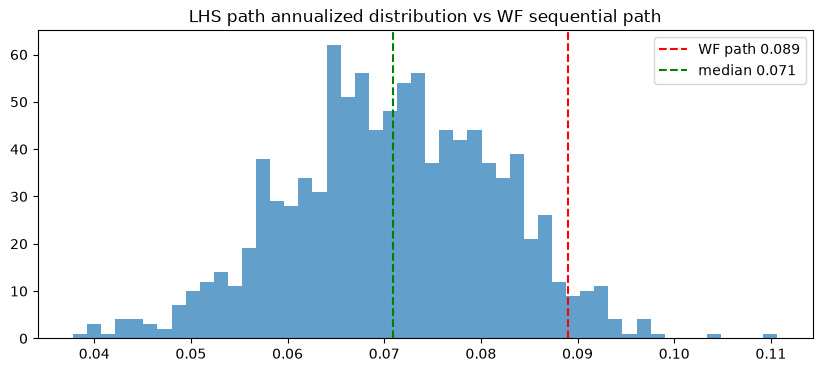

In [17]:

fold_paths = adaptive_multi_paths(X, folds, test_size=126, train_size=int(252*2.5),
                                  n_test_folds=2, n_jobs=8)   # 与搜索cell12一致

# ---- 跨折LHS组合: test两折独立段, 每折2个段单元(路径数随折可变: 5或7) -> 完整OOS路径分布 ----
folds_list = sorted(fold_paths.keys())
n_blocks = len(fold_paths[0][0])                      # 每路径test段块数(2)
all_test_parts = []                                   # 段单元: (折, 块), 共 len(folds_list)*2 个
for i in folds_list:
    for b in range(n_blocks):
        all_test_parts.append([fold_paths[i][pid][b] for pid in sorted(fold_paths[i])])
# 超立方采样，每条=段单元数个Portfolio元组
samples = discrete_lhs_safe(all_test_parts, n_samples=1000, seed=42)   

# 路径图: 1000条组合路径累计收益
#Population([MultiPeriodPortfolio(sample, compounded=False) for sample in samples]).plot_cumulative_returns()

# 年化分布
path_anns = np.array([MultiPeriodPortfolio(sample).annualized_mean for sample in samples])

wf_ann = MultiPeriodPortfolio([f["test"] for f in folds[:]]).annualized_mean

print(f"LHS多路径分布({len(path_anns)}条): 均值 {path_anns.mean():.4f} | 中位 {np.median(path_anns):.4f} | "
      f"5% {np.percentile(path_anns,5):.4f} | 95% {np.percentile(path_anns,95):.4f}")
print(f"WF真实路径: {wf_ann:.4f} | 分布中 {(wf_ann-path_anns.mean())/path_anns.std():.2f}σ | "
      f"分位 {(path_anns < wf_ann).mean():.1%}")

plt.figure(figsize=(10,4))
plt.hist(path_anns, bins=50, alpha=0.7)
plt.axvline(x=wf_ann, c='red', ls='--', label=f'WF path {wf_ann:.3f}')
plt.axvline(x=np.median(path_anns), c='green', ls='--', label=f'median {np.median(path_anns):.3f}')
plt.legend(); plt.title('LHS path annualized distribution vs WF sequential path'); plt.show()


LHS多路径分布(1000条): 均值 0.5316 | 中位 0.5320 | 5% 0.3967 | 95% 0.6562
WF真实路径: 0.6880 | 分布中 1.92σ | 分位 97.7%


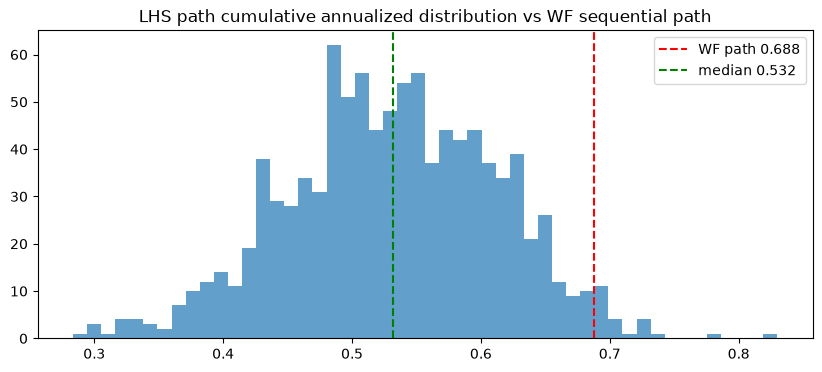

In [18]:
# 年化分布
path_anns = np.array([MultiPeriodPortfolio(sample).cumulative_returns[-1] for sample in samples])

wf_ann = MultiPeriodPortfolio([f["test"] for f in folds[:]]).cumulative_returns[-1]

print(f"LHS多路径分布({len(path_anns)}条): 均值 {path_anns.mean():.4f} | 中位 {np.median(path_anns):.4f} | "
      f"5% {np.percentile(path_anns,5):.4f} | 95% {np.percentile(path_anns,95):.4f}")
print(f"WF真实路径: {wf_ann:.4f} | 分布中 {(wf_ann-path_anns.mean())/path_anns.std():.2f}σ | "
      f"分位 {(path_anns < wf_ann).mean():.1%}")

plt.figure(figsize=(10,4))
plt.hist(path_anns, bins=50, alpha=0.7)
plt.axvline(x=wf_ann, c='red', ls='--', label=f'WF path {wf_ann:.3f}')
plt.axvline(x=np.median(path_anns), c='green', ls='--', label=f'median {np.median(path_anns):.3f}')
plt.legend(); plt.title('LHS path cumulative annualized distribution vs WF sequential path'); plt.show()


In [ ]:
MultiPeriodPortfolio([f["test"] for f in folds[:]]).plot_cumulative_returns()

In [ ]:
Population([MultiPeriodPortfolio(sample, compounded=False) for sample in samples]).plot_cumulative_returns()

In [21]:
# ===== 每折自适应参数一览 =====
rows = []
for f in folds:
    p = dict(f["params"])
    p["fitness"] = str(p["fitness_measures"])
    del p["fitness_measures"]
    rows.append({"fold": f["fold"], "inner_median": round(f["inner_median"], 4), **p})
print(pd.DataFrame(rows).to_string(index=False))

 fold  inner_median  threshold  min_n_assets  corr_threshold  train_size                                 fitness
    0       -0.0188       -0.5             5             0.1         504      [Mean, Variance, Average Drawdown]
    1       -0.0134       -0.5            10             0.1         378 [Mean, Semi-Variance, Average Drawdown]
    2        0.3270       -0.5             5             0.1         252 [Mean, Semi-Variance, Average Drawdown]
    3        0.1824       -0.4            15             0.1         504      [Mean, Variance, Average Drawdown]
    4        0.3260       -0.5            10             0.2         252 [Mean, Semi-Variance, Average Drawdown]
    5        0.2335       -0.4            10             0.2         378 [Mean, Semi-Variance, Average Drawdown]
    6        0.0668       -0.5             5             0.1         378      [Mean, Variance, Average Drawdown]
    7        0.4074       -0.5            10             0.1         378 [Mean, Semi-Variance, A

In [22]:
MultiPeriodPortfolio([f["test"] for f in folds[:]]).summary()

Mean                                     0.035%
Annualized Mean                           8.90%
Variance                                0.0021%
Annualized Variance                       0.52%
Semi-Variance                           0.0011%
Annualized Semi-Variance                  0.27%
Standard Deviation                        0.45%
Annualized Standard Deviation             7.21%
Semi-Deviation                            0.32%
Annualized Semi-Deviation                 5.16%
Mean Absolute Deviation                   0.25%
CVaR at 95%                               1.04%
EVaR at 95%                               3.31%
Worst Realization                         6.71%
CDaR at 95%                               4.74%
MAX Drawdown                             10.32%
Average Drawdown                          0.98%
EDaR at 95%                               6.52%
First Lower Partial Moment                0.13%
Ulcer Index                               0.015
Gini Mean Difference                    

 CPCV 路径结果计算 PBO 和 Deflated Sharpe Ratio (DSR) 的核心代码

In [ ]:
import numpy as np
from scipy.stats import skew, kurtosis, norm
from scipy.integrate import quad

In [150]:
def diagnose_oos_lhs(lhs_paths, annual_factor=252, risk_free_rate=0.02, n_trials=1):
    """
    纯 OOS 策略诊断 (复用离散 LHS 采样路径 + MultiPeriodPortfolio)

    Parameters:
        lhs_paths: list, discrete_lhs_safe 的返回结果——每条元素是一个
                   MultiPeriodPortfolio 的 block 组合（tuple of Portfolio），
                   即采样后的路径列表，无需重新采样
        annual_factor: int, 年化交易日
        risk_free_rate: float, 无风险利率
        n_trials: int, DSR 的独立试验数 N（整个流程被独立评估并挑选最优的次数）;
        纯 OOS 单流程无跨数据集挑选 -> 取 1
    """
    n_samples = len(lhs_paths)
    # OOS 总天数 = 首条路径各 block returns 长度之和（各路径等长）
    T_total = sum(len(np.asarray(part.returns)) for part in lhs_paths[0])

    print(f"[Info] {n_samples} LHS paths | OOS {T_total} days")

    # ==========================================================
    # 1. 逐条路径构造 MultiPeriodPortfolio → returns / MDD 矩阵
    # ==========================================================
    full_paths = np.empty((n_samples, T_total))
    mc_mdds = np.empty(n_samples)
    for i, path in enumerate(lhs_paths):
        mpp = MultiPeriodPortfolio(path)
        rets = np.asarray(mpp.returns, dtype=float)
        full_paths[i] = np.nan_to_num(rets, nan=0.0)
        mc_mdds[i] = mpp.max_drawdown          # skfolio 口径（负值，同绩效表 max_drawdown）

    # ==========================================================
    # 2. Sharpe
    # ==========================================================
    excess = full_paths - (risk_free_rate / annual_factor)
    means = excess.mean(axis=1)
    stds = full_paths.std(axis=1, ddof=1)
    stds = np.where(stds < 1e-12, 1e-12, stds)
    oos_sharpes = (means / stds) * np.sqrt(annual_factor)

    # ==========================================================
    # 3. DSR（偏度/峰度取首条采样路径，与 Sharpe 同用超额收益）
    # ==========================================================
    gamma3 = skew(excess[0])
    gamma4 = kurtosis(excess[0]) + 3

    sr_obs = np.median(oos_sharpes)

    # e_max = E[max_N Z]: N 个独立标准正态最大值的期望, 数值积分对任意 N 精确;
    # Bailey & López de Prado(2014) 渐近式仅对大 N 有效, N 小时失真
    def expected_max_std_normal(n):
        if n <= 1:
            return 0.0
        def integrand(z):
            return z * norm.pdf(z) * norm.cdf(z) ** (n - 1)
        val, _ = quad(integrand, -8.0, 8.0, limit=400)
        return n * val

    e_max = expected_max_std_normal(n_trials)
    # Lo(2002) Sharpe 方差项: 系数 (γ4-1)/4 (原代码误写 /24)
    inflation = max(1 - gamma3 * sr_obs + (gamma4 - 1) * sr_obs ** 2 / 4, 1e-8)
    # z = t(SR_obs) - e_max: e_max 为标准化 z 单位, 不能再乘 sqrt(T-1)
    z_score = np.sqrt(max(T_total - 1, 1)) * sr_obs / np.sqrt(inflation) - e_max
    dsr = norm.cdf(z_score)
    prob_loss = np.mean(oos_sharpes <= 0)

    # ==========================================================
    # 4. Report
    # ==========================================================
    print("\n" + "=" * 60)
    print("          纯 OOS 策略诊断报告 (LHS)")
    print("=" * 60)
    print(f"  ✅ P(SR<=0)              : {prob_loss:.2%}")
    print(f"  ✅ Sharpe 90% CI         : [{np.percentile(oos_sharpes, 5):.3f}, "
          f"{np.percentile(oos_sharpes, 95):.3f}]")
    print(f"  ✅ MDD median / worst-5%  : {np.median(mc_mdds):.2%} / "
          f"{np.percentile(mc_mdds, 95):.2%}")
    print("-" * 60)
    print(f"  ⚠️ SR_obs (median)       : {sr_obs:.4f}")
    print(f"  ⚠️ DSR                   : {dsr:.4f}  (z={z_score:.2f}, n_trials={n_trials})")
    print("=" * 60)

    return {
        "prob_loss": prob_loss, "dsr": dsr, "sr_obs": sr_obs,
        "e_max": e_max, "z_score": z_score,
        "mc_sharpes": oos_sharpes, "mc_mdds": mc_mdds,
        "T_total": T_total, "n_trials": n_trials
    }

## 消融实验
通过消融实验，对比，动态选择是否显著优于，固定参数和固定train_size。

 2×2 消融矩阵

| | train_size 固定(504) | train_size 自适应 |
|---|---|---|
| **参数固定** | A2 | A4 |
| **参数自适应** | A3 | A1 |

五组对比各自回答的问题：

- **A1 vs A2**：整体增益（动态选择 vs 全固定）
- **A1 vs A3**：train_size 自适应的边际贡献（在参数自适应前提下）
- **A1 vs A4**：参数自适应的边际贡献（在 train_size 自适应前提下）
- **A3 vs A2**：参数自适应的边际贡献（train_size 固定时）
- **A4 vs A2**：train_size 自适应的边际贡献（参数固定时）

归因结论模式：

- `A1 ≈ A3 > A2`：增益主要来自**参数自适应**，train_size 自适应可省 → 简化模型
- `A1 ≈ A4 > A2`：增益主要来自 **train_size 自适应**
- `A3 ≈ A4 ≈ A2 < A1`：两者**交互作用**才有增益，单拆哪个都不行

A1 基于目标函数筛选出来的每折参数：
```
fold  inner_median  threshold  min_n_assets  corr_threshold  train_size                                 fitness
    0       -0.0188       -0.5             5             0.1         504      [Mean, Variance, Average Drawdown]
    1       -0.0134       -0.5            10             0.1         378 [Mean, Semi-Variance, Average Drawdown]
    2        0.3270       -0.5             5             0.1         252 [Mean, Semi-Variance, Average Drawdown]
    3        0.1824       -0.4            15             0.1         504      [Mean, Variance, Average Drawdown]
    4        0.3260       -0.5            10             0.2         252 [Mean, Semi-Variance, Average Drawdown]
    5        0.2335       -0.4            10             0.2         378 [Mean, Semi-Variance, Average Drawdown]
    6        0.0668       -0.5             5             0.1         378      [Mean, Variance, Average Drawdown]
    7        0.4074       -0.5            10             0.1         378 [Mean, Semi-Variance, Average Drawdown]
    8       -0.0053       -0.5             5             0.1         378      [Mean, Variance, Average Drawdown]
    9        0.0009       -0.5            10             0.1         504      [Mean, Variance, Average Drawdown]
   10        0.2563       -0.4            15             0.1         252      [Mean, Variance, Average Drawdown]
   11        0.6157       -0.5             5             0.1         252      [Mean, Variance, Average Drawdown]
   12       -0.1666       -0.4            15             0.1         252      [Mean, Variance, Average Drawdown]
   13       -0.3211       -0.5             5             0.3         378      [Mean, Variance, Average Drawdown]
   14       -0.2117       -0.5            15             0.3         504      [Mean, Variance, Average Drawdown]
   15        0.2823       -0.5             5             0.1         378      [Mean, Variance, Average Drawdown]
```

A3 固定T,搜索对照组参数:
```
fold  inner_median  threshold  min_n_assets  corr_threshold  train_size                                 fitness
    0       -0.0377       -0.4            15             0.1         504      [Mean, Variance, Average Drawdown]
    1       -0.2217       -0.5            10             0.2         504      [Mean, Variance, Average Drawdown]
    2       -0.0367       -0.5            15             0.1         504 [Mean, Semi-Variance, Average Drawdown]
    3        0.1824       -0.4            10             0.1         504      [Mean, Variance, Average Drawdown]
    4       -0.0501       -0.5            15             0.1         504 [Mean, Semi-Variance, Average Drawdown]
    5        0.0514       -0.5            15             0.2         504 [Mean, Semi-Variance, Average Drawdown]
    6        0.0576       -0.4            10             0.1         504      [Mean, Variance, Average Drawdown]
    7        0.1376       -0.4            10             0.1         504      [Mean, Variance, Average Drawdown]
    8       -0.2451       -0.4            10             0.1         504 [Mean, Semi-Variance, Average Drawdown]
    9        0.0009       -0.5            15             0.1         504      [Mean, Variance, Average Drawdown]
   10        0.2214       -0.5             5             0.1         504 [Mean, Semi-Variance, Average Drawdown]
   11       -0.1149       -0.5             5             0.1         504 [Mean, Semi-Variance, Average Drawdown]
   12       -0.2881       -0.4            10             0.1         504      [Mean, Variance, Average Drawdown]
   13       -0.5779       -0.5            15             0.1         504 [Mean, Semi-Variance, Average Drawdown]
   14       -0.2117       -0.5            15             0.3         504      [Mean, Variance, Average Drawdown]
   15       -0.1163       -0.5            10             0.2         504      [Mean, Variance, Average Drawdown]
```

A4 固定参数P,搜索对照组T参数：
```
fold  inner_median  threshold  min_n_assets  corr_threshold  train_size                            fitness
    0       -0.0188       -0.5             5             0.1         504 [Mean, Variance, Average Drawdown]
    1       -0.0979       -0.5             5             0.1         252 [Mean, Variance, Average Drawdown]
    2        0.3040       -0.5             5             0.1         378 [Mean, Variance, Average Drawdown]
    3        0.1848       -0.5             5             0.1         504 [Mean, Variance, Average Drawdown]
    4        0.2384       -0.5             5             0.1         252 [Mean, Variance, Average Drawdown]
    5        0.0169       -0.5             5             0.1         378 [Mean, Variance, Average Drawdown]
    6        0.0668       -0.5             5             0.1         378 [Mean, Variance, Average Drawdown]
    7        0.1112       -0.5             5             0.1         504 [Mean, Variance, Average Drawdown]
    8       -0.0053       -0.5             5             0.1         378 [Mean, Variance, Average Drawdown]
    9        0.0009       -0.5             5             0.1         504 [Mean, Variance, Average Drawdown]
   10        0.2080       -0.5             5             0.1         252 [Mean, Variance, Average Drawdown]
   11        0.6157       -0.5             5             0.1         252 [Mean, Variance, Average Drawdown]
   12       -0.2946       -0.5             5             0.1         504 [Mean, Variance, Average Drawdown]
   13       -0.3625       -0.5             5             0.1         378 [Mean, Variance, Average Drawdown]
   14        0.3569       -0.5             5             0.1         252 [Mean, Variance, Average Drawdown]
   15        0.2823       -0.5             5             0.1         378 [Mean, Variance, Average Drawdown]
```

In [ ]:
# ===== A3' 重搜: 固定 train_size=504, 其余参数自适应 =====
param_grid_tfixed = {
    "threshold_range": (-0.5, -0.4),
    "min_n_assets": (5, 15, 5),
    "fitness_measures": FITNESS_MEASURES,
    "corr_range": (0.1, 0.3),
    "train_size": (504, 504, 126),   # start=stop=504 -> suggest_int 恒返回 504
}
folds_tfixed = nested_adaptive_search(X, test_size=126, train_size=int(252*2.5),
                                      n_test_folds=2, n_jobs=12, n_trials=100,
                                      param_grid=param_grid_tfixed, verbose=True)

# 与 selected_params 同构的字典（params 里 train_size 天然全是 504）
A3_params_a = [{"fold": f["fold"], "params": f["params"]} for f in folds_tfixed]

In [ ]:
# ===== A4' 重搜: 参数固定(A2全局最优), train_size 自适应 =====
param_grid_pfixed = {
    "threshold_range": (-0.5, -0.5),   # 固定
    "min_n_assets": (5, 5, 5),         # 固定
    "fitness_measures": {"mean-variance-avgdd": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN]},  # 固定
    "corr_range": (0.1, 0.1),          # 固定
    "train_size": (252, 504, 126),     # 唯一自适应维度
}
folds_pfixed = nested_adaptive_search(X, test_size=126, train_size=int(252*2.5),
                                      n_test_folds=2, n_jobs=12, n_trials=10,
                                      param_grid=param_grid_pfixed, verbose=True)

In [85]:
# A1: WalkForward + CPCV ,每折搜到一组自适应参数
A1_params = [
    {"fold": 0,  "params": {"min_n_assets": 5,  "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 504}},
    {"fold": 1,  "params": {"min_n_assets": 10, "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.SEMI_VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 378}},
    {"fold": 2,  "params": {"min_n_assets": 5,  "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.SEMI_VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 252}},
    {"fold": 3,  "params": {"min_n_assets": 15, "threshold": -0.4, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 504}},
    {"fold": 4,  "params": {"min_n_assets": 10, "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.SEMI_VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.2, "train_size": 252}},
    {"fold": 5,  "params": {"min_n_assets": 10, "threshold": -0.4, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.SEMI_VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.2, "train_size": 378}},
    {"fold": 6,  "params": {"min_n_assets": 5,  "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 378}},
    {"fold": 7,  "params": {"min_n_assets": 10, "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.SEMI_VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 378}},
    {"fold": 8,  "params": {"min_n_assets": 5,  "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 378}},
    {"fold": 9,  "params": {"min_n_assets": 10, "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 504}},
    {"fold": 10, "params": {"min_n_assets": 15, "threshold": -0.4, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 252}},
    {"fold": 11, "params": {"min_n_assets": 5,  "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 252}},
    {"fold": 12, "params": {"min_n_assets": 15, "threshold": -0.4, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 252}},
    {"fold": 13, "params": {"min_n_assets": 5,  "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.3, "train_size": 378}},
    {"fold": 14, "params": {"min_n_assets": 15, "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.3, "train_size": 504}},
    {"fold": 15, "params": {"min_n_assets": 5,  "threshold": -0.5, "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], "corr_threshold": 0.1, "train_size": 378}},
]

# A2: WalkForward + GridSearch 搜到一组全局固定参数
A2_params = [
    {"fold": f["fold"], "params": {
        "min_n_assets": 5, "threshold": -0.5,
        "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN],
        "corr_threshold": 0.1, "train_size": 504,   # 252*2 固定，与方案A口径一致
    }}
    for f in selected_params
]

# A3: 复制A1的自适应参数 + train_size 固定 504
#A3_params = [
#    {"fold": f["fold"], "params": {**f["params"], "train_size": 504}}
#    for f in A1_params
#]
A3_params = A3_params_a

# A4: 参数固定 + train_size 复制A1的自适应
FIXED_FILTER = {
    "min_n_assets": 5, "threshold": -0.5,
    "fitness_measures": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN],
    "corr_threshold": 0.1,
}
A4_params = [
    {"fold": f["fold"], "params": {**FIXED_FILTER, "train_size": f["params"]["train_size"]}}
    for f in folds_pfixed
]

In [ ]:
# 基于消融参数组合和CPCV生成OOS的路径片段
selected_paths = adaptive_multi_paths(X, A1_params, test_size=126, train_size=int(252*2.5), n_test_folds=2, n_jobs=8)   
all_fixed_paths = adaptive_multi_paths(X, A2_params, test_size=126, train_size=int(252*2.5), n_test_folds=2, n_jobs=8) 
train_fixed_paths = adaptive_multi_paths(X, A3_params, test_size=126, train_size=int(252*2.5), n_test_folds=2, n_jobs=8)
param_fixed_paths = adaptive_multi_paths(X, A4_params, test_size=126,train_size=int(252*2.5), n_test_folds=2, n_jobs=8)

In [88]:
# 拆开fold_path, 按oos（test)时序排序，得到路径片段嵌套列表
selected_path_folds = build_test_parts(selected_paths, n_test_folds=2)
all_fixed_path_folds = build_test_parts(all_fixed_paths, n_test_folds=2)
train_fixed_path_folds = build_test_parts(train_fixed_paths, n_test_folds=2)
param_fixed_path_folds = build_test_parts(param_fixed_paths, n_test_folds=2)
# 超立方采样的到路径
A1_oos_lhs_paths = discrete_lhs_safe(selected_path_folds, n_samples=10000)
A2_oos_lhs_paths = discrete_lhs_safe(all_fixed_path_folds, n_samples=10000)
A3_oos_lhs_paths = discrete_lhs_safe(train_fixed_path_folds, n_samples=10000)
A4_oos_lhs_paths = discrete_lhs_safe(param_fixed_path_folds, n_samples=10000)

1. 统计描述：核心指标

In [91]:
# ============================================================
# 消融实验结果分析 (A1-A4) —— 核心指标版
# 收益 | 波动风险 | 回撤风险 | 尾部风险 | 风险收益比
# ============================================================

METRICS = ["annualized_mean", "annualized_standard_deviation",
           "max_drawdown", "cvar", "annualized_sharpe_ratio"]
BETTER_HIGHER = {"annualized_mean": True, "annualized_sharpe_ratio": True}
NEUTRAL = set()

# Step 1: MPP 缓存（每条路径只构造一次）
mpps = {
    "A1 全自适应":          [MultiPeriodPortfolio(s) for s in A1_oos_lhs_paths],
    "A2 全固定":            [MultiPeriodPortfolio(s) for s in A2_oos_lhs_paths],
    "A3 参数自适应(t固定)": [MultiPeriodPortfolio(s) for s in A3_oos_lhs_paths],
    "A4 t自适应(参数固定)": [MultiPeriodPortfolio(s) for s in A4_oos_lhs_paths],
}

def extract_metrics(mpp_list, metrics=METRICS):
    return pd.DataFrame([[getattr(m, met) for met in metrics] for m in mpp_list],
                        columns=metrics)

frames = {name: extract_metrics(ms) for name, ms in mpps.items()}
median_tbl = pd.DataFrame({name: df.median() for name, df in frames.items()}).T

median_tbl.round(4)

,annualized_mean,annualized_standard_deviation,max_drawdown,cvar,annualized_sharpe_ratio
A1 全自适应,0.0710,0.0748,0.0961,0.0114,0.9484
A2 全固定,0.0788,0.0747,0.1116,0.0110,1.0640
A3 参数自适应(t固定),0.0775,0.0706,0.0890,0.0105,1.0972
A4 t自适应(参数固定),0.0642,0.0713,0.1101,0.0109,0.8992


In [138]:
log_result(median_tbl, section="2.1 核心指标中位数(四组)")

[log] D:\machine-learning-for-trading\case_studies\lazy_trading\logs\WalkForward+CPCV+PS.log  +=  2.1 核心指标中位数(四组) @ 2026-08-30 21:51:12


WindowsPath('D:/machine-learning-for-trading/case_studies/lazy_trading/logs/WalkForward+CPCV+PS.log')

2. 2×2 消融显著性

In [92]:
from scipy.stats import mannwhitneyu

def boot_diff_ci(a, b, n_boot=3000, seed=42):
    rng = np.random.default_rng(seed)
    na, nb = len(a), len(b)
    diffs = np.array([rng.choice(a, na, replace=True).mean()
                      - rng.choice(b, nb, replace=True).mean() for _ in range(n_boot)])
    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])

PAIRS = [
    ("A1-A2 整体",      "A1 全自适应",          "A2 全固定"),
    ("A1-A3 t自适应",   "A1 全自适应",          "A3 参数自适应(t固定)"),
    ("A1-A4 参数自适应", "A1 全自适应",          "A4 t自适应(参数固定)"),
    ("A3-A2 参数边际",  "A3 参数自适应(t固定)",  "A2 全固定"),
    ("A4-A2 t边际",     "A4 t自适应(参数固定)",  "A2 全固定"),
]

rows = []
for m in METRICS:
    for label, ga, gb in PAIRS:
        a, b = frames[ga][m], frames[gb][m]
        diff, ci = boot_diff_ci(a, b)
        p = mannwhitneyu(a, b).pvalue
        verdict = ("提升" if (p < 0.05 and ci[0] > 0) else
                   "下降" if (p < 0.05 and ci[1] < 0) else "不显著")
        if not BETTER_HIGHER.get(m, False):
            verdict = {"提升": "下降", "下降": "提升"}.get(verdict, "不显著")
        rows.append({"metric": m, "pair": label, "diff": diff,
                     "ci_lo": ci[0], "ci_hi": ci[1], "p": p, "verdict": verdict})
sig = pd.DataFrame(rows)
sig.pivot_table(index="metric", columns="pair", values="verdict", aggfunc="first")

pair,A1-A2 整体,A1-A3 t自适应,A1-A4 参数自适应,A3-A2 参数边际,A4-A2 t边际
metric,,,,,
annualized_mean,下降,下降,提升,下降,下降
annualized_sharpe_ratio,下降,下降,提升,提升,下降
annualized_standard_deviation,不显著,下降,下降,提升,提升
cvar,下降,下降,下降,提升,提升
max_drawdown,提升,下降,提升,提升,不显著


In [140]:
log_result(sig.pivot_table(index="metric", columns="pair", values="verdict", aggfunc="first"),
           section="2.2 显著性矩阵"
)

[log] D:\machine-learning-for-trading\case_studies\lazy_trading\logs\WalkForward+CPCV+PS.log  +=  2.2 显著性矩阵 @ 2026-08-30 21:53:38


WindowsPath('D:/machine-learning-for-trading/case_studies/lazy_trading/logs/WalkForward+CPCV+PS.log')

多重检验校正

In [142]:
from statsmodels.stats.multitest import multipletests

sig["p_adj"] = multipletests(sig["p"], method="fdr_bh")[1]
sig["verdict_adj"] = [
    ("提升" if (pa < 0.05 and r["ci_lo"] > 0) else
     "下降" if (pa < 0.05 and r["ci_hi"] < 0) else "不显著")
    for r, pa in zip(sig.to_dict("records"), sig["p_adj"])]

log_result(sig.pivot_table(index="metric", columns="pair", values="verdict", aggfunc="first"),
           section="2.2 显著性矩阵(FDR校正)"
)
sig.pivot_table(index="metric", columns="pair", values="verdict_adj", aggfunc="first")

[log] D:\machine-learning-for-trading\case_studies\lazy_trading\logs\WalkForward+CPCV+PS.log  +=  2.2 显著性矩阵(FDR校正) @ 2026-08-30 21:55:45


pair,A1-A2 整体,A1-A3 t自适应,A1-A4 参数自适应,A3-A2 参数边际,A4-A2 t边际
metric,,,,,
annualized_mean,下降,下降,提升,下降,下降
annualized_sharpe_ratio,下降,下降,提升,提升,下降
annualized_standard_deviation,不显著,提升,提升,下降,下降
cvar,提升,提升,提升,下降,下降
max_drawdown,下降,提升,下降,下降,不显著


In [ ]:
concl = []
for m in METRICS:
    g = sig[sig["metric"] == m].set_index("pair")
    def win(pair): return g.loc[pair, "verdict"] == "提升"
    o, t, p_ = win("A1-A2 整体"), win("A1-A3 t自适应"), win("A1-A4 参数自适应")
    src = ("两者都有贡献" if o and t and p_ else
           "主要来自 train_size" if o and t else
           "主要来自参数自适应" if o and p_ else
           "交互效应(单拆不显著)" if o else "无显著增益")
    concl.append({"指标": m, "A1优于A2": o, "增益来源": src})

print(pd.DataFrame(concl).to_string(index=False))

                           指标  A1优于A2      增益来源
              annualized_mean   False     无显著增益
annualized_standard_deviation   False     无显著增益
                 max_drawdown    True 主要来自参数自适应
                         cvar   False     无显著增益
      annualized_sharpe_ratio   False     无显著增益


3. 可视化

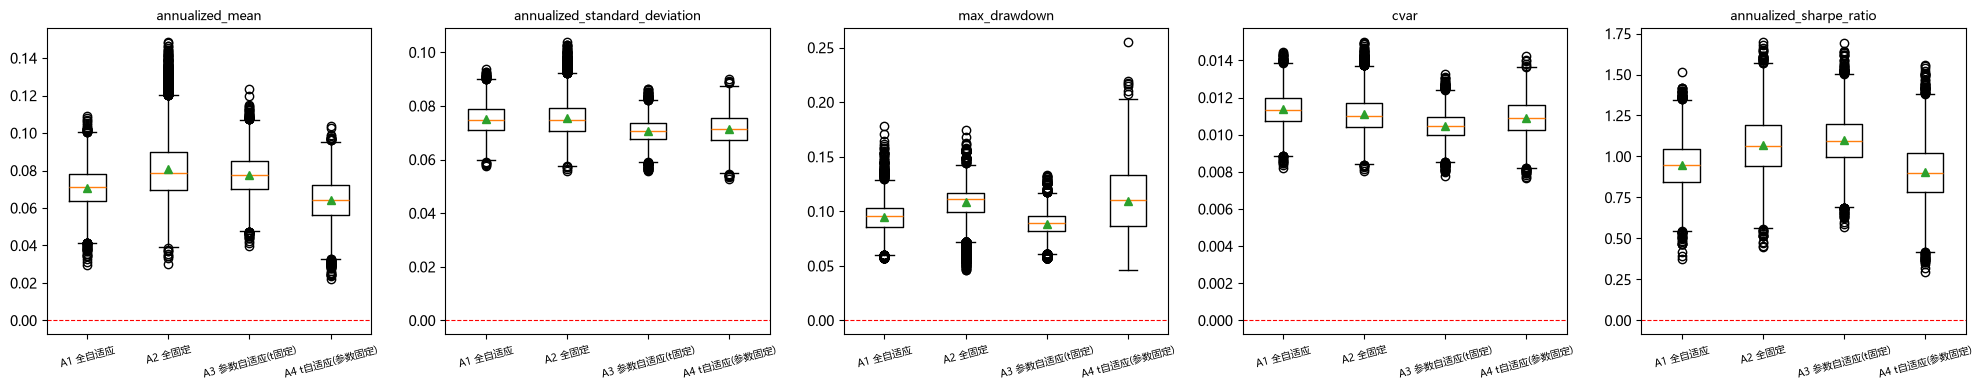

In [94]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, m in zip(axes, METRICS):
    bp = ax.boxplot([frames[k][m] for k in frames], showmeans=True)
    ax.set_xticklabels(list(frames.keys()), rotation=15, fontsize=7)
    ax.axhline(0, color='red', ls='--', lw=0.8)
    ax.set_title(m, fontsize=9)
plt.tight_layout()
plt.show()

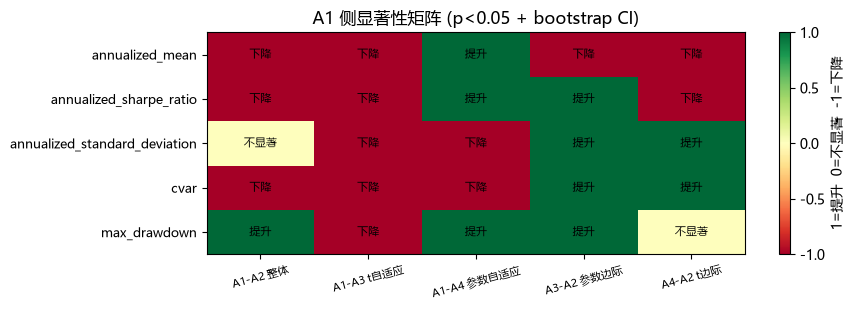

In [95]:
# Step 3d: 显著性矩阵热力图（一眼看全 5 指标 × 5 对比）
verdict_map = {"提升": 1, "不显著": 0, "下降": -1}
mat = sig.pivot_table(index="metric", columns="pair", values="verdict", aggfunc="first")
mat_num = mat.replace(verdict_map).astype(float)

plt.figure(figsize=(9, 3.2))
plt.imshow(mat_num.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
plt.xticks(range(len(mat.columns)), mat.columns, rotation=15, fontsize=8)
plt.yticks(range(len(mat.index)), mat.index, fontsize=9)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        plt.text(j, i, mat.values[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(label="1=提升  0=不显著  -1=下降")
plt.title("A1 侧显著性矩阵 (p<0.05 + bootstrap CI)")
plt.tight_layout()
plt.show()

4. 可选：完整诊断（补 DSR / Sharpe / MDD）

In [152]:
res_a3_4 = diagnose_oos_lhs(A3_oos_lhs_paths, n_trials=1)

[Info] 10000 LHS paths | OOS 1890 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 0.00%
  ✅ Sharpe 90% CI         : [0.572, 1.059]
  ✅ MDD median / worst-5%  : 8.90% / 10.33%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 0.8139
  ⚠️ DSR                   : 1.0000  (z=21.54, n_trials=1)


In [151]:
res_a3_4 = diagnose_oos_lhs(A3_oos_lhs_paths, n_trials=4)

[Info] 10000 LHS paths | OOS 1890 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 0.00%
  ✅ Sharpe 90% CI         : [0.572, 1.059]
  ✅ MDD median / worst-5%  : 8.90% / 10.33%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 0.8139
  ⚠️ DSR                   : 1.0000  (z=20.51, n_trials=4)


OOS 分阶段稳健性

In [143]:
# 每折(时间段)的夏普中位数: 组 × fold 热力图, 检查优势是否均匀
fold_sharpe = {}
for name, fold_paths_ in [("A1", selected_paths), ("A2", all_fixed_paths),
                          ("A3", train_fixed_paths), ("A4", param_fixed_paths)]:
    fold_sharpe[name] = []
    for i in sorted(fold_paths_):
        srs = [MultiPeriodPortfolio([fold_paths_[i][pid][b] for pid in sorted(fold_paths_[i])]).annualized_sharpe_ratio
               for b in range(2)]
        fold_sharpe[name].append(np.mean(srs))
log_result(pd.DataFrame(fold_sharpe).T.round(3), section="4.1 OSS分阶段稳健性")
pd.DataFrame(fold_sharpe).T.round(3)

[log] D:\machine-learning-for-trading\case_studies\lazy_trading\logs\WalkForward+CPCV+PS.log  +=  4.1 OSS分阶段稳健性 @ 2026-08-30 21:58:24


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
A1,0.821,1.040,1.227,1.433,1.199,2.925,-0.379,0.777,0.336,1.214,0.791,0.582,1.643,2.084,0.621
A2,0.821,1.818,1.911,1.435,0.633,2.285,0.445,-0.045,0.497,1.214,0.733,0.592,1.709,1.922,0.437
A3,0.693,1.970,1.971,1.433,0.442,3.469,0.457,-0.045,0.415,1.214,0.992,0.472,1.653,1.698,0.621
A4,0.821,0.936,2.177,1.435,0.629,2.163,-0.379,-0.045,0.336,1.214,0.462,0.582,1.709,1.633,0.241


相邻 OOS 段的持仓换手率 (0~1)

In [123]:
# ===== 换手率: weights(数组) + assets 对齐 =====
def turnover_series(fold_paths, n_test_folds=2):
    tos = []
    prev_w, prev_a = None, None
    for i in sorted(fold_paths):
        pid = sorted(fold_paths[i])[0]
        for b in range(n_test_folds):
            ptf = fold_paths[i][pid][b]
            w, a = ptf.weights, ptf.assets          # 数组, 与 assets 对应
            if prev_w is not None:
                common = np.union1d(prev_a, a)
                w1 = np.zeros(len(common)); w2 = np.zeros(len(common))
                w1[np.isin(common, prev_a)] = prev_w
                w2[np.isin(common, a)] = w
                tos.append(0.5 * np.abs(w1 - w2).sum())
            prev_w, prev_a = w, a
    return pd.Series(tos)

to_a2 = turnover_series(all_fixed_paths)
to_a3 = turnover_series(train_fixed_paths)
print(f"A2 换手中位: {to_a2.median():.1%} | 年化 ≈ {to_a2.median()*2:.0%}")
print(f"A3 换手中位: {to_a3.median():.1%} | 年化 ≈ {to_a3.median()*2:.0%}")
print(f"增量(参数自适应): {to_a3.median()-to_a2.median():.1%}/半年")

A2 换手中位: 66.7% | 年化 ≈ 133%
A3 换手中位: 71.4% | 年化 ≈ 143%
增量(参数自适应): 4.8%/半年


基准联动（沪深300ETF）

——用 canonical 路径（每折 block0 拼接）对 A3 和基准做净值对比 + 超额统计：

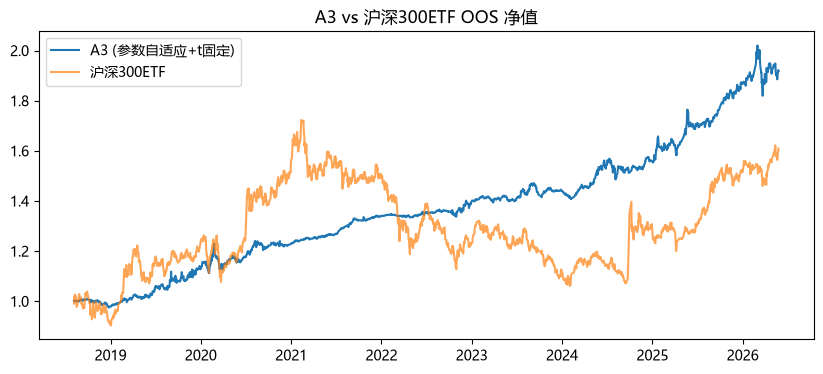

In [132]:
# ===== 基准联动: 直接用现成的 MPP =====
start = all_fixed_paths[0][0][0].returns_df.index[0]
end = all_fixed_paths[len(all_fixed_paths) - 1][0][1].returns_df.index[-1]

mpp = mpps["A3 参数自适应(t固定)"][999]      # 现成的: LHS 路径已由 MultiPeriodPortfolio 拼接
rets = mpp.returns                         # 现成的: 组合复合收益率
if isinstance(rets, np.ndarray):           # 仅兜底索引(returns 无索引时)
    rets = pd.Series(rets, index=mpp.returns_df.index, name="A3")

nav_a3 = (1 + rets).cumprod()
bench_ret_oos = bench_ret.loc[start:end].reindex(nav_a3.index).ffill()
bench_nav = (1 + bench_ret_oos).cumprod()

plt.figure(figsize=(10, 4))
plt.plot(nav_a3.index, nav_a3.values, label="A3 (参数自适应+t固定)")
plt.plot(bench_nav.index, bench_nav.values, label="沪深300ETF", alpha=0.7)
plt.legend(); plt.title("A3 vs 沪深300ETF OOS 净值")
plt.show()

In [145]:
# ===== A3 vs 沪深300: 修正口径 (几何超额 = 相对净值年化) =====
start = all_fixed_paths[0][0][0].returns_df.index[0]
end = all_fixed_paths[len(all_fixed_paths) - 1][0][1].returns_df.index[-1]
bench_full = bench_ret.loc[start:end]
bench_ann = (1 + bench_full).prod() ** (252 / len(bench_full)) - 1

rng = np.random.default_rng(42)
idx = rng.choice(len(mpps["A3 参数自适应(t固定)"]), size=1000, replace=False)
sample = [mpps["A3 参数自适应(t固定)"][i] for i in idx]

excess_stats = []
for mpp in sample:
    r = mpp.returns
    if isinstance(r, np.ndarray):
        r = pd.Series(r, index=mpp.returns_df.index, name="A3")
    e = r - bench_full.reindex(r.index).ffill()
    excess_stats.append([
        (1 + mpp.annualized_mean) / (1 + bench_ann) - 1,  # 几何超额(相对净值年化)
        e.mean() * 252,                                    # 算术超额
        e.mean() / e.std() * np.sqrt(252),                 # IR (口径不变)
        (e > 0).mean(),                                    # 日胜率 (口径不变)
    ])

df_ex = pd.DataFrame(excess_stats, columns=["ann_excess", "arith_excess", "IR", "winrate"])
log_result(df_ex.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%", "mean"]].round(4),
           section="4.2 A3 vs 沪深300 相对收益分布")
print(df_ex.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%", "mean"]].round(4))

[log] D:\machine-learning-for-trading\case_studies\lazy_trading\logs\WalkForward+CPCV+PS.log  +=  4.2 A3 vs 沪深300 相对收益分布 @ 2026-08-30 22:02:50
      ann_excess  arith_excess      IR  winrate
5%       -0.0056       -0.0191 -0.1151   0.5069
50%       0.0109       -0.0015 -0.0089   0.5159
95%       0.0285        0.0172  0.1036   0.5249
mean      0.0108       -0.0016 -0.0096   0.5158


In [129]:
# 基准同口径风险指标
b = bench_ret.loc[start:end].reindex(nav_a3.index).ffill()   # nav_a3 任意一条路径的索引即可
bench_nav = (1 + b).cumprod()
print(f"沪深300 年化收益: {(1+b).prod()**(252/len(b))-1:.2%}")
print(f"沪深300 年化波动: {b.std()*np.sqrt(252):.2%}")
print(f"沪深300 MDD:      {-((bench_nav/bench_nav.cummax()-1).min()):.2%}")
print(f"沪深300 夏普(粗): {(1+b).prod()**(252/len(b))-1 - 0.02:.2f}")  # rf≈2%

# 对照 A3(消融表已有)
print(f"A3 年化波动: 7.06% | MDD: -8.60% | 夏普: 1.0972")

沪深300 年化收益: 6.55%
沪深300 年化波动: 17.43%
沪深300 MDD:      38.47%
沪深300 夏普(粗): 0.05
A3 年化波动: 7.06% | MDD: -8.60% | 夏普: 1.0972
